# Image classification with CNNs

Learn about image classification with CNNs, the difference between the binary and multi-class image classification models, and how to use transfer learning for image classification in PyTorch.

## 1. Prepare environment

In [1]:
# Importing libraries
import expectexception
import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import PIL
import torchvision

from environment import prepare_environment
from pprint import pprint

from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.transforms import functional
from torchvision.models import (resnet18, ResNet18_Weights,
                                resnet50, ResNet50_Weights,
                                list_models)
from torchvision.io import read_image

In [2]:
# Check if your GPU driver and CUDA is enabled and accessible by PyTorch
print(torch.__version__)
print('Cuda is available?', torch.cuda.is_available())

2.4.1+cu124
Cuda is available? True


In [3]:
# Global variables
SEED = 42

GPU_DEVICE = torch.cuda.current_device() if torch.cuda.is_available() else None

DATASET_CATS_AND_DOGS_TRAIN = "data-sources/cats_and_dogs/training_set/"
DATASET_CATS_AND_DOGS_TEST = "data-sources/cats_and_dogs/test_set/"

ARTIFACTS_FOLDER = "artifacts/"

In [4]:
# Global configuration
prepare_environment()

torch.set_printoptions(precision=10)
torch.set_default_dtype(torch.float32)

# Reproducibility
np.random.seed(SEED)
_ = torch.manual_seed(SEED)

In [5]:
# Util functions
def show_tensor_image(image:[torch.Tensor, PIL.Image.Image],
                      title:str='Tensor Image') -> None:
    fig = plt.figure(figsize=(2, 2))
    plt.title(title)
    plt.axis('off')
    plt.imshow(image.permute(1, 2, 0))
    plt.show()

## 2. Work with ResNet18

In [6]:
# Pretrained ResNet18
class PredictWithResNet18:
    def __init__(self):
        # Step 1: Initialize model with the best available weights
        self.weights = ResNet18_Weights.DEFAULT
        self.categories = self.weights.meta["categories"]
        self.model = resnet18(weights=self.weights)
        self.model.eval()

        # Step 2: Initialize the inference transforms
        self.preprocess = self.weights.transforms()
        
    def predict(self, image_file: str):
        # Read the image
        image = read_image(image_file)

        # Step 3: Apply inference preprocessing transforms
        batch = self.preprocess(image).unsqueeze(0)

        # Step 4: Use the model and print the predicted category
        with torch.no_grad():
            prediction = self.model(batch).squeeze(0).softmax(0)
        class_id = prediction.argmax().item()
        score = prediction[class_id].item()
        category_name = self.categories[class_id]
        return {category_name: 100 * score}

### Read image and predict

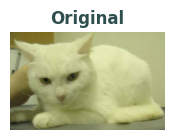

{'Egyptian cat': 38.95748853683472}

In [7]:
# Getting the input image = Another reading method
image_file = 'data-sources/channels-example/cat.13.jpg'
image = read_image(image_file)
show_tensor_image(image, title='Original')

model_resnet18 = PredictWithResNet18()
model_resnet18.predict(image_file)

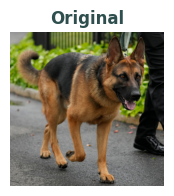

{'German shepherd': 96.17097973823547}

In [8]:
# Getting the input image = Another reading method
image_file = 'data-sources/channels-example/dog-rgb.jpg'
image = read_image(image_file)
show_tensor_image(image, title='Original')

model_resnet18 = PredictWithResNet18()
model_resnet18.predict(image_file)

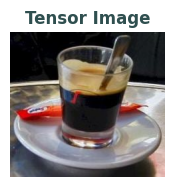

{'espresso': 34.62789058685303}


In [9]:
# Read image
image_file = 'data-sources/channels-example/Espresso.jpeg'
image = read_image(image_file)
show_tensor_image(image)

# Using our previous class PredictWithResNet18
print(model_resnet18.predict(image_file))

## 3. Work with ResNet50

In [10]:
# Pretrained ResNet50
class PredictWithResNet50:
    def __init__(self):
        # Step 1: Initialize model with the best available weights
        self.weights = ResNet50_Weights.DEFAULT
        self.categories = self.weights.meta["categories"]
        self.model = resnet50(weights=self.weights)
        self.model.eval()

        # Step 2: Initialize the inference transforms
        self.preprocess = self.weights.transforms()
        
    def predict(self, image_file: str):
        # Read the image
        image = read_image(image_file)

        # Step 3: Apply inference preprocessing transforms
        batch = self.preprocess(image).unsqueeze(0)

        # Step 4: Use the model and print the predicted category
        with torch.no_grad():
            prediction = self.model(batch).squeeze(0).softmax(0)
        class_id = prediction.argmax().item()
        score = prediction[class_id].item()
        category_name = self.categories[class_id]
        return {category_name: 100 * score}

### Read image and predict

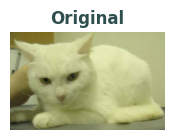

{'Angora': 28.397610783576965}

In [11]:
# Getting the input image = Another reading method
image_file = 'data-sources/channels-example/cat.13.jpg'
image = read_image(image_file)
show_tensor_image(image, title='Original')

model_resnet50 = PredictWithResNet50()
model_resnet50.predict(image_file)

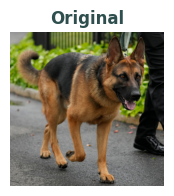

{'German shepherd': 17.11370050907135}

In [12]:
# Getting the input image = Another reading method
image_file = 'data-sources/channels-example/dog-rgb.jpg'
image = read_image(image_file)
show_tensor_image(image, title='Original')

model_resnet50 = PredictWithResNet50()
model_resnet50.predict(image_file)

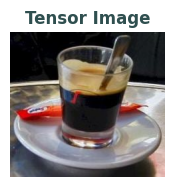

{'espresso': 40.334174036979675}


In [13]:
# Read image
image_file = 'data-sources/channels-example/Espresso.jpeg'
image = read_image(image_file)
show_tensor_image(image)

# Using our previous class PredictWithResNet50
print(model_resnet50.predict(image_file))

---------------------------